# Description 

The fig 8 is divided in several parts ploted in python separatly described below. They were then reassembled and eddited in Canva to facilitate the edditing. 

# Libraries importation

In [7]:
import sys
sys.path.insert(1, '/home/bricej/MyPythonLibrary/StageM2_IVT/library/')
import domain
from domain import *
from climbas import *
import geopandas as gpd
import numpy as np
import xarray as xr
import pandas as pd
from netCDF4 import Dataset
from scipy import stats
import scipy.stats as stats
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, MultiPolygon
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle

# Part 1 : Map of the subregions where we have glacier evolution data

For more details for the subregions definition : shapefile created and saved in '/home/bricej/MyPythonLibrary/StageM2_IVT/papier/himap_grouped_regions_hugonnet'

In [8]:
# shapefile with the polygons of the suberegions
dg = gpd.read_file('/bettik/PROJECTS/pr-regional-climate/bricej/HIMAP_grouped_regions/himap_grouped_regions.shp')

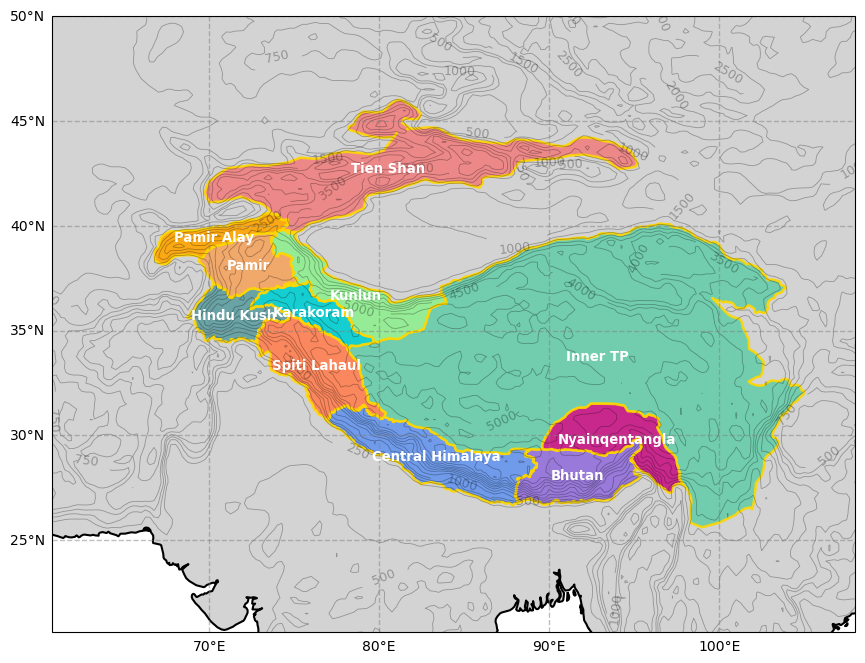

In [10]:
# couleurs des subregions
group_colors = {
    "Tien Shan": "lightcoral",
    "Pamir Alay": "orange",
    "Pamir": "sandybrown",
    "Hindu Kush": "cadetblue",
    "Karakoram": "darkturquoise",
    "Kunlun": "lightgreen",
    "Spiti Lahaul": "coral",
    "Central Himalaya": "cornflowerblue",
    "Bhutan": "mediumpurple",
    "Nyainqentangla": "mediumvioletred",
    "Inner TP": "mediumaquamarine"
}

#figure
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# polygone des subregions avec contour en "gold" et remplie avec sa couleur associée
dg.plot(ax=ax,color = dg["Primary_ID"].map(group_colors),edgecolor="gold",linewidth=1.8,alpha=0.9)

ax.coastlines(linewidth=1.5) # coastline
ax.add_feature(cfeature.LAND,facecolor="lightgrey") # land

# courbes de niveau
elev = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/bricej/gmted/gmted_on_era5_MA.nc')['elevation'] # elevation data
SH = ax.contour(elev.longitude,elev.latitude,elev,levels=[250,500,750,1000,1500,2000,2500,3000,3500,4000,4500,5000,5500,6000,6500,7000],
                colors="black",linewidths=0.6,alpha=0.3,transform=ccrs.PlateCarree()) # contour lines
ax.clabel(SH, inline=True, fontsize=9, fmt="%d") # label des courbes de niveau

# labels des régions
for idx, row in dg.iterrows():
    centroid = row.geometry.centroid # centroïde de la région
    ax.text(
        centroid.x,centroid.y, # coordonnées du centroïde des régions (x=lon, y=lat)
        row["Primary_ID"],fontsize=9.5,fontweight='bold',ha='center',va='center',color='white', # label text parameters
        transform=ccrs.PlateCarree(),zorder=5)

# étendre les limites de la figure
bounds = dg.total_bounds # [minx, miny, maxx, maxy] (x=lon, y=lat)
ax.set_extent([bounds[0]-6, bounds[2]+3, bounds[1]-5, bounds[3]+4],crs=ccrs.PlateCarree())

# grille lat lon
gl = ax.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

plt.show()

# Part 2 : Subplots for the different subregions : annual cycle of precipitation & temperature (ERA5, 1960-2025)

## Period wanted

In [14]:
iyear = 1960
fyear = 2019

## Subregions with galcier evolution data

In [15]:
domains = ["Tien Shan", "Pamir Alay", "Pamir", "Hindu Kush", "Karakoram", 
           "Kunlun", "Spiti Lahaul", "Central Himalaya","Bhutan", "Nyainqentangla", "Inner TP"]

## Variables needed for temperature and precipitation

t2m = 2m above surface temperature, tp = total precipitation, sf = snowfall, rf = rainfall

In [16]:
variables = ['t2m','tp','sf','rf']

## Monthly mean on the 1960-2019 period data loading

This data were computed by doing a temporal and a spatial mean in every subregion. For more details, it was computed in : /StageM2_IVT/papier/compute_monthly-mean_var_era5_HIMAPgrouped_final_regions

In [17]:
# path to the monthly mean data for the different variables
path = '/bettik/PROJECTS/pr-regional-climate/bricej/paper/'

var_mean = {} # dictionnary to store the data

for var in variables:
    monthly_mean = pd.read_csv(f'{path}{var}_era5_monthly_mean_HIMAPgrouped_regions_{iyear}-{fyear}.csv')
    var_mean[var] = monthly_mean

var_mean['t2m'].iloc[:, 1:] = var_mean['t2m'].iloc[:, 1:] - 273.15 # conversion Kelvin -> °C

# months of the year
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

# selection of the variable wanted
sf_df = var_mean['sf'].set_index("region")[months] # sf
rf_df = var_mean['rf'].set_index("region")[months] # rf
tp_df = var_mean['tp'].set_index("region")[months] # tp
t2m_df = var_mean['t2m'].set_index("region")[months] # t2m

## Annual total precipitation (mm/year)

In [23]:
total_precip = {} # dictionnary to store annual total tp

for dom in domains:
    tp = tp_df.loc[dom].values
    tot = np.sum(tp) # cumulated through the year
    total_precip[dom] = tot

## Annual mean temperature (°C)

In [24]:
mean_t2m = {} # dictionnary to store  annual mean t2m

for dom in domains:
    t2m = t2m_df.loc[dom].values
    mean = np.mean(t2m) # mean through the year
    mean_t2m[dom] = mean

## Plot of the subplots

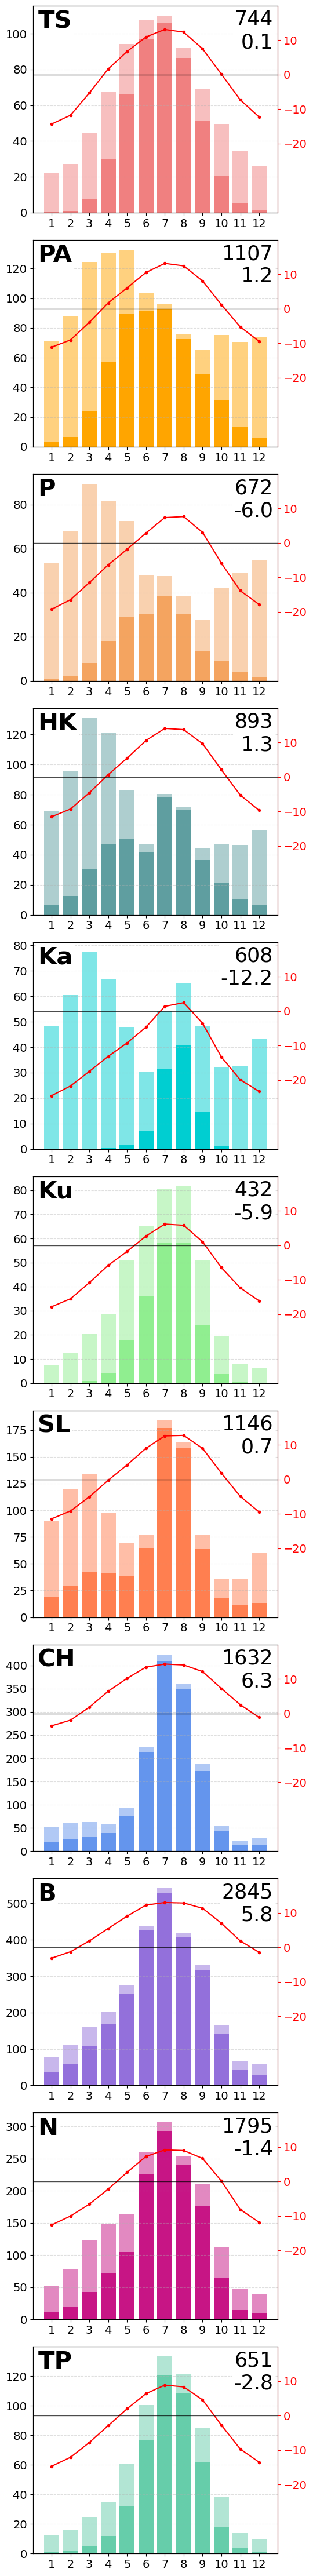

In [26]:
# letters for the subregions initials
letters = ['TS', 'PA', 'P', 'HK', 'Ka', 'Ku', 'SL', 'CH', 'B', 'N', 'TP']

# number associated with the month of the year 1 -> 12 (1=January, 12=December)
x = np.arange(1,13)

# figure
fig, axes = plt.subplots(len(domains), 1, figsize=(5.5, 45))

for i, dom in enumerate(domains):
    ax = axes[i]

    # axe droit : t2m (red)
    ax2 = ax.twinx()
    ax2.tick_params(axis='y', colors='red')
    ax2.yaxis.label.set_color('red')
    ax2.spines['right'].set_color('red')

    # selectionner juste les valeurs
    rf = rf_df.loc[dom].values
    sf = sf_df.loc[dom].values
    tp = tp_df.loc[dom].values
    t2m = t2m_df.loc[dom].values

    # rf barplot
    ax.bar(x, rf, label='rf', color=group_colors[dom])

    # sf barplot par dessus rf
    ax.bar(x, sf, bottom=rf, label='sf', color=group_colors[dom], alpha=0.5)

    # t2m on right axis
    ax2.plot(x, t2m,marker='o', linestyle='-',color='red',label=f't2m',linewidth=1.5, markersize=3)
    ax2.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha = 0.7) # ligne hironztale pour t2m = 0°C
    
    # échelle et décalage de l'axe droit (t2m). Le même pour toutes les régions.
    ax2.set_ylim(bottom=-40, top=20) 
    ticks = np.arange(-40, 20, 10)
    ticks_filtered = ticks[(ticks >= -20) & (ticks <= 20)]
    ax2.set_yticks(ticks_filtered)
    ax2.tick_params(axis='y', labelsize=14)

    ax.grid(axis='y', linestyle='--', alpha=0.4)

    # labelsize des ax-y & ax-x
    ax.tick_params(axis='y', labelsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(x, fontsize=14)

    # letter for subregion initials
    ax.text(0.02, 0.98,f'{letters[i]}',transform=ax.transAxes,fontsize=30,fontweight='bold',va='top',ha='left',
            bbox=dict(facecolor='white', edgecolor='none', alpha=1, pad=2), zorder=15)

    # annual total tp value top right (mm/year)
    # annual mean t2m value top right (°C)
    ax.text(0.98, 0.98,f'{total_precip[dom]:.0f}\n{mean_t2m[dom]:.1f}',transform=ax.transAxes,fontsize=25,va='top',ha='right',
            bbox=dict(facecolor='white', edgecolor='none', alpha=1, pad=2), zorder=15)

plt.tight_layout(rect=[0, 0.01, 1, 1]) # [left, bottom, right, top]
plt.show()

# Part 3 : Legend of the subplots

Legend values correspond to the annual total precipitation and annual mean temperature of all regions together.

### Merge all the region together to have total of precipitation and mean of temperature in all domain

In [28]:
# Sur tout le domaine
rf_total_domain = np.array([rf_df.loc[dom].values for dom in domains]).sum(axis=0) # annual total rf
sf_total_domain = np.array([sf_df.loc[dom].values for dom in domains]).sum(axis=0) # annual total sf
tp_all = np.array([tp_df.loc[dom].values for dom in domains]).sum(axis=0) # annual total of tp
t2m_mean_domain = np.array([t2m_df.loc[dom].values for dom in domains]).mean(axis=0) # annual mean t2m

### Plot the legend

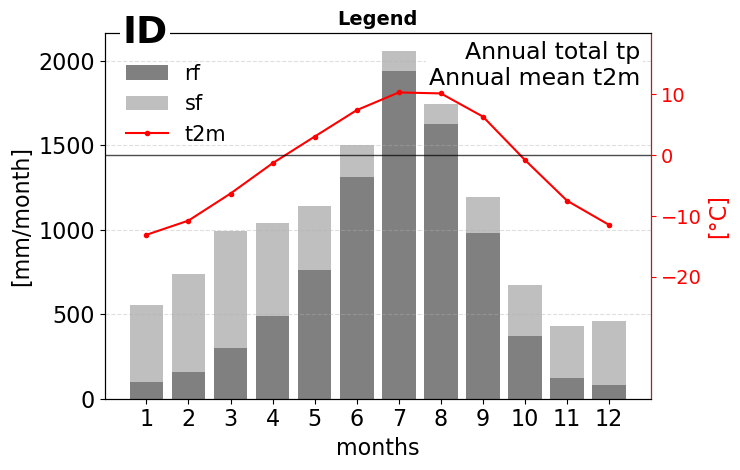

In [43]:
# figure
fig, ax = plt.subplots(figsize=(7.5, 5))

# variables
rf = rf_total_domain
sf = sf_total_domain
tp = tp_all
t2m = t2m_mean_domain

# axe droit : t2m (red)
ax2 = ax.twinx() 
ax2.tick_params(axis='y', colors='red')
ax2.yaxis.label.set_color('red')
ax2.spines['right'].set_color('red')

# rf barplot
ax.bar(x, rf, label='rf', color='gray')

# # sf barplot par dessus rf
ax.bar(x, sf, bottom=rf, label='sf', color='gray', alpha=0.5)

# t2m on right axis
ax2.plot(x, t2m,marker='o', linestyle='-',color='red',label=f't2m',linewidth=1.5, markersize=3)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha = 0.7)

# échelle et décalage de l'axe droit (t2m)
ax2.set_ylim(bottom=-40, top=20) 
ticks = np.arange(-40, 20, 10)
ticks_filtered = ticks[(ticks >= -20) & (ticks <= 20)]
ax2.set_yticks(ticks_filtered)
ax2.tick_params(axis='y', labelsize=14)
ax2.set_ylabel('[°C]', fontsize=16)

ax.set_title('Legend', fontsize=14, weight='bold')

ax.grid(axis='y', linestyle='--', alpha=0.4)

# label et labelsize des ax-y & ax-x
ax.set_ylabel('[mm/month]', fontsize=16)
ax.set_xlabel('months', fontsize=16)
ax.tick_params(axis='y', labelsize=16)
ax.set_xticks(x)
ax.set_xticklabels(x, fontsize=16)

# légende
handles1, labels1 = ax.get_legend_handles_labels() # axe gauche (rf, sf)
handles2, labels2 = ax2.get_legend_handles_labels() # axe droit (t2m)
fig.legend(handles1 + handles2,labels1 + labels2,loc='upper left',bbox_to_anchor=(0.15, 0.9),ncol=1,fontsize=15,frameon=False)

# letter for subregion initials
fig.text(0.17, 0.96,'ID',fontsize=27,fontweight='bold',ha='left',va='top', bbox=dict(facecolor='white', edgecolor='none', alpha=1, pad=2))

# annual total tp & annual mean t2m legend (top right)
ax.text(0.98, 0.98,f'Annual total tp\nAnnual mean t2m',transform=ax.transAxes,fontsize=17,va='top',ha='right',
            bbox=dict(facecolor='white', edgecolor='none', alpha=1, pad=2), zorder=15)

plt.tight_layout(rect=[0, 0.04, 1, 1]) # [left, bottom, right, top]
plt.show()